In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import ibis
import polars as pl
from ibis import deferred as _

from datasets.mini import fx
from pvm.pvm import PVM

In [15]:
# Preview the FX dataset
fx

product,country,year,volume,price_in_lc,fx_rate,price,revenue
str,str,i64,i64,f64,f64,f64,f64
"""A""","""US""",2020,100,20.0,1.0,20.0,2000.0
"""A""","""US""",2021,100,20.0,1.0,20.0,2000.0
"""B""","""China""",2020,300,12.0,0.6,7.2,2160.0
"""B""","""China""",2021,360,11.8,0.65,7.67,2761.2
"""B""","""Japan""",2020,250,15.0,0.8,12.0,3000.0
"""B""","""Japan""",2021,180,18.0,0.6,10.8,1944.0
"""C""","""China""",2020,200,3.0,0.6,1.8,360.0
"""C""","""China""",2021,270,2.9,0.65,1.885,508.95
"""C""","""Japan""",2020,200,6.0,0.8,4.8,960.0


In [16]:
fx.group_by("year").agg(
    total_revenue=pl.col("revenue").sum(),
    total_volume=pl.col("volume").sum(),
).with_columns(average_price=pl.col("total_revenue") / pl.col("total_volume"))

year,total_revenue,total_volume,average_price
i64,f64,i64,f64
2020,8480.0,1050,8.07619
2021,7934.15,1060,7.485047


In [17]:
## add charts

In [ ]:
import altair as alt

base = alt.Chart(fx).encode(
    x=alt.X("year:O", axis=alt.Axis(labelAngle=0, title=None)),
)

volume = (
    base.mark_bar(opacity=0.6)
    .encode(
        y=alt.Y("volume:Q", title="Volume"),
        tooltip=["product:N", "country:N", "year:O", "volume:Q"],
    )
    .properties(width=50, height=100)
    .facet(
        column=alt.Column("product:N", header=alt.Header(titleOrient="bottom")),
        row="country:N",
        title="Volume",
    )
)

price = (
    base.mark_line(point=True, color="orange")
    .encode(
        y=alt.Y("price:Q", title="Price (USD)"),
        tooltip=["product:N", "country:N", "year:O", alt.Tooltip("price:Q", format=".2f")],
    )
    .properties(width=50, height=100)
    .facet(
        column=alt.Column("product:N", header=alt.Header(titleOrient="bottom")),
        row=alt.Row("country:N", header=None),
        title="Price (USD)",
    )
)

lc_price = (
    base.mark_line(point=True, color="orange")
    .encode(
        y=alt.Y("price_in_lc:Q", title="Price (Local Currency)"),
        tooltip=["product:N", "country:N", "year:O", alt.Tooltip("price_in_lc:Q", format=".2f")],
    )
    .properties(width=50, height=100)
    .facet(
        column=alt.Column("product:N", header=alt.Header(titleOrient="bottom")),
        row=alt.Row("country:N", header=None),
        title="Price (in local currency)",
    )
)

volume | lc_price | price

alt.HConcatChart(...)

In [19]:
agg = (
    fx.group_by("year")
    .agg(revenue=pl.col("revenue").sum(), volume=pl.col("volume").sum())
    .with_columns(price=pl.col("revenue") / pl.col("volume"))
    .sort("year")
)

p0, q0 = agg["price"][0], agg["volume"][0]
p1, q1 = agg["price"][1], agg["volume"][1]

pl.DataFrame(
    {
        "effect": ["volume", "price"],
        "value": [(q1 - q0) * p0, (p1 - p0) * q1],
    }
)

effect,value
str,f64
"""volume""",80.761905
"""price""",-626.611905


## Manual price & volume effect calculation

Using the classic PVM decomposition:
- **Volume effect** = (Q₁ − Q₀) × P₀  — how much revenue changed purely due to volume
- **Price effect** = (P₁ − P₀) × Q₁  — how much revenue changed purely due to price

In [20]:
# Create an ibis connection to the FX data
con = ibis.polars.connect({"fx": fx})
sales = con.table("fx")

In [21]:
from pvm.measures import Measure, QuantityMeasure, RateMeasure

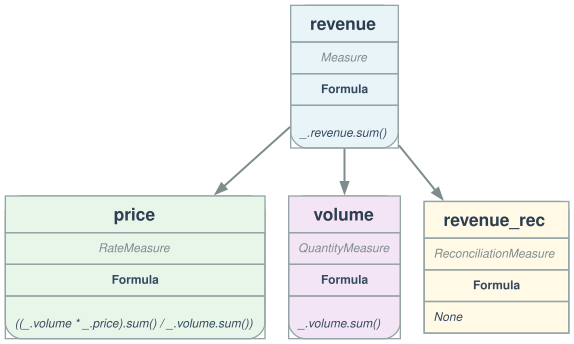

In [22]:
# Build a revenue graph with price and volume components
revenue_graph = Measure(
    "revenue",
    definition=_.revenue.sum(),
    components=[
        RateMeasure(
            "price",
            definition=(_.volume * _.price).sum() / _.volume.sum(),
        ),
        QuantityMeasure(
            "volume",
            definition=_.volume.sum(),
        ),
    ],
)

revenue_graph.display()

In [23]:
pvm_with_mix = (
    PVM().set_data(sales).set_periods(_.year, ["2020", "2021"]).set_hierarchy([_.product]).set_graph(revenue_graph)
)

pvm_with_mix.get_effects().to_polars().group_by("measure").agg(pl.col("value").sum())

measure,value
str,f64
"""price""",-518.031818
"""volume""",-27.818182


## Price-volume effects with product mix

The totals-only analysis above hides **mix effects**: changes in which products were sold affect the average price even if individual product prices are unchanged. Adding `product` to the hierarchy decomposes effects at the product level and surfaces this.

In [24]:
# Set up PVM analysis: compare 2020 vs 2021

pvm_analysis = PVM().set_data(sales).set_periods(_.year, ["2020", "2021"]).set_hierarchy([]).set_graph(revenue_graph)

In [25]:
# Calculate price/volume effects
effects = pvm_analysis.get_effects().to_polars()
effects

L1,L2,measure,period,value
str,str,str,str,f64
"""revenue""","""volume""","""volume""","""2020""",80.761905
"""revenue""","""price""","""price""","""2020""",-626.611905


In [26]:
pvm_analysis = (
    PVM()
    .set_data(sales)
    .set_periods(_.year, ["2020", "2021"])
    .set_hierarchy(["country", "product"])
    .set_graph(revenue_graph)
)
# Calculate price/volume effects
effects = pvm_analysis.get_effects().to_polars()
effects.group_by("measure").agg(pl.col("value").sum())

measure,value
str,f64
"""volume""",-522.0
"""price""",-23.85


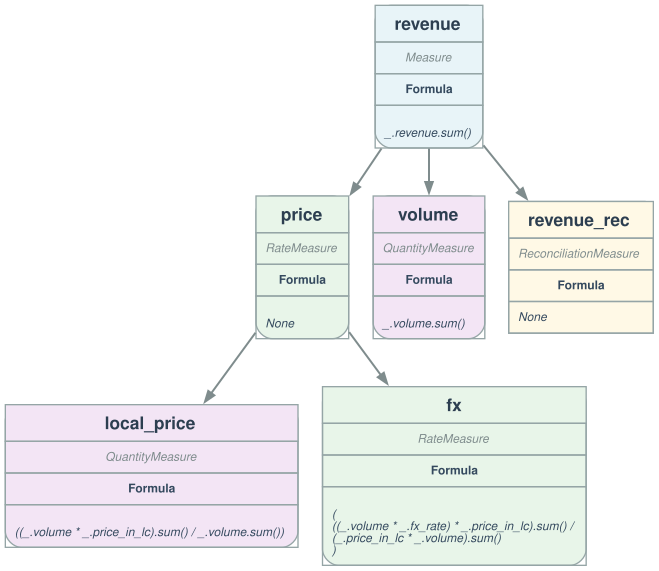

In [34]:
# Build a revenue graph with price and volume components

price = RateMeasure(
    "price",
    components=[
        QuantityMeasure("local_price", definition=(_.volume * _.price_in_lc).sum() / _.volume.sum()),
        RateMeasure(
            "fx",
            definition=(_.volume * _.fx_rate * _.price_in_lc).sum() / (_.price_in_lc * _.volume).sum(),
        ),
    ],
)

revenue_graph_with_fx = Measure(
    "revenue",
    definition=_.revenue.sum(),
    components=[
        price,
        QuantityMeasure(
            "volume",
            definition=_.volume.sum(),
        ),
    ],
)

revenue_graph_with_fx.display()

In [33]:
pvm_analysis_with_fx = (
    PVM()
    .set_data(sales)
    .set_periods(_.year, ["2020", "2021"])
    .set_hierarchy(["country", "product"])
    .set_graph(revenue_graph_with_fx)
)
# Calculate price/volume effects
effects = pvm_analysis_with_fx.get_effects().to_polars()
effects.group_by("measure", "country").agg(pl.col("value").sum()).pivot(index="country", on="measure", values="value")

country,fx,volume,local_price
str,f64,f64,f64
"""US""",0.0,0.0,0.0
"""Japan""",-888.0,-1080.0,672.0
"""China""",251.55,558.0,-59.4


In [42]:
# Build a revenue graph with price and volume components

wrong_price = RateMeasure(
    "price",
    components=[
        QuantityMeasure("local_price", definition=(_.volume * _.price_in_lc).sum() / _.volume.sum()),
        RateMeasure(
            "fx",
            definition=(_.volume * _.fx_rate).sum() / (_.volume).sum(),
        ),
    ],
)

wrong_revenue_graph_with_fx = Measure(
    "revenue",
    definition=_.revenue.sum(),
    components=[
        wrong_price,
        QuantityMeasure(
            "volume",
            definition=_.volume.sum(),
        ),
    ],
)

wrong_pvm_analysis_with_fx = (
    PVM()
    .set_data(sales)
    .set_periods(_.year, ["2020", "2021"])
    .set_hierarchy(["country", "product"])
    .set_graph(wrong_revenue_graph_with_fx)
)
# Calculate price/volume effects
wrong_effects = wrong_pvm_analysis_with_fx.get_effects().to_polars()
wrong_effects.group_by("measure", "country").agg(pl.col("value").sum()).pivot(
    index="country", on="measure", values="value"
)

country,local_price,fx,volume
str,f64,f64,f64
"""China""",-59.4,251.55,558.0
"""US""",0.0,0.0,0.0
"""Japan""",672.0,-888.0,-1080.0
